<a href="https://colab.research.google.com/github/xiyuan1avery/ma2288/blob/main/notebooks/04_identity_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Identity Baseline

This notebook evaluates a no-transition baseline:

$$
\hat{h}_{t+k} = h_t
$$

It measures how much the true hidden state and output distribution change
over rollout horizons of 1, 2, 4, 8, 16, and 32 tokens.

In [1]:
!pip install -q transformers pandas matplotlib seaborn

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
DRIVE_DIRECTORY = Path(
    "/content/drive/MyDrive/ma2288_nextlat"
)

TEST_DATA_PATH = (
    DRIVE_DIRECTORY
    / "test_teacher_states.pt"
)

print("Test data path:", TEST_DATA_PATH)
print("File exists:", TEST_DATA_PATH.exists())

Test data path: /content/drive/MyDrive/ma2288_nextlat/test_teacher_states.pt
File exists: True


In [5]:
test_artifact = torch.load(
    TEST_DATA_PATH,
    map_location="cpu",
    weights_only=False,
)

test_token_ids = test_artifact["token_ids"]
test_hidden_states = test_artifact["hidden_states"]

print("Model:", test_artifact["model_name"])
print("Token shape:", test_token_ids.shape)
print("Hidden shape:", test_hidden_states.shape)
print("Hidden dtype:", test_hidden_states.dtype)

Model: distilgpt2
Token shape: torch.Size([80, 64])
Hidden shape: torch.Size([80, 64, 768])
Hidden dtype: torch.float16


In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = test_artifact["model_name"]

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

model = model.to(device)
model.eval()

for parameter in model.parameters():
    parameter.requires_grad = False

print("Model loaded:", MODEL_NAME)
print("Vocabulary size:", model.config.vocab_size)
print("Hidden dimension:", model.config.n_embd)

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded: distilgpt2
Vocabulary size: 50257
Hidden dimension: 768


In [7]:
example_hidden = (
    test_hidden_states[0, 10]
    .float()
    .to(device)
)

with torch.no_grad():
    example_logits = model.lm_head(example_hidden)

print("Hidden shape:", example_hidden.shape)
print("Logit shape:", example_logits.shape)

Hidden shape: torch.Size([768])
Logit shape: torch.Size([50257])


In [8]:
HORIZONS = [1, 2, 4, 8, 16, 32]

# 对每个文本 block 测试几个不同起始位置
START_POSITIONS = [0, 8, 16, 24, 31]

print("Horizons:", HORIZONS)
print("Start positions:", START_POSITIONS)

for horizon in HORIZONS:
    for start_position in START_POSITIONS:
        assert (
            start_position + horizon
            < test_hidden_states.shape[1]
        )

print("All start-position and horizon combinations are valid.")

Horizons: [1, 2, 4, 8, 16, 32]
Start positions: [0, 8, 16, 24, 31]
All start-position and horizon combinations are valid.


In [9]:
def compute_latent_metrics(
    predicted_hidden,
    true_hidden,
):
    """
    Compute hidden-state error for each sample.

    Both inputs have shape:
        [batch_size, hidden_dimension]
    """

    difference = predicted_hidden - true_hidden

    absolute_l2 = torch.linalg.vector_norm(
        difference,
        dim=-1,
    )

    true_norm = torch.linalg.vector_norm(
        true_hidden,
        dim=-1,
    )

    normalized_l2 = absolute_l2 / (
        true_norm + 1e-8
    )

    cosine_similarity = F.cosine_similarity(
        predicted_hidden,
        true_hidden,
        dim=-1,
    )

    return normalized_l2, cosine_similarity

In [10]:
OUTPUT_BATCH_SIZE = 16


def compute_output_metrics(
    predicted_hidden,
    true_hidden,
):
    """
    Compare language-model output distributions.

    Returns:
        KL(true distribution || predicted distribution)
        top-1 token agreement
    """

    all_kl = []
    all_top1_agreement = []

    number_of_samples = predicted_hidden.shape[0]

    for start in range(
        0,
        number_of_samples,
        OUTPUT_BATCH_SIZE,
    ):
        end = min(
            start + OUTPUT_BATCH_SIZE,
            number_of_samples,
        )

        predicted_batch = (
            predicted_hidden[start:end]
            .float()
            .to(device)
        )

        true_batch = (
            true_hidden[start:end]
            .float()
            .to(device)
        )

        with torch.no_grad():
            predicted_logits = model.lm_head(
                predicted_batch
            )

            true_logits = model.lm_head(
                true_batch
            )

            predicted_log_probabilities = (
                F.log_softmax(
                    predicted_logits,
                    dim=-1,
                )
            )

            true_log_probabilities = (
                F.log_softmax(
                    true_logits,
                    dim=-1,
                )
            )

            true_probabilities = torch.exp(
                true_log_probabilities
            )

            kl_divergence = torch.sum(
                true_probabilities
                * (
                    true_log_probabilities
                    - predicted_log_probabilities
                ),
                dim=-1,
            )

            predicted_top1 = torch.argmax(
                predicted_logits,
                dim=-1,
            )

            true_top1 = torch.argmax(
                true_logits,
                dim=-1,
            )

            top1_agreement = (
                predicted_top1 == true_top1
            ).float()

        all_kl.append(
            kl_divergence.cpu()
        )

        all_top1_agreement.append(
            top1_agreement.cpu()
        )

    return (
        torch.cat(all_kl),
        torch.cat(all_top1_agreement),
    )

In [11]:
def collect_hidden_pairs_for_horizon(horizon):
    predicted_list = []
    true_list = []

    for block_index in range(
        test_hidden_states.shape[0]
    ):
        for start_position in START_POSITIONS:
            current_hidden = (
                test_hidden_states[
                    block_index,
                    start_position,
                ]
            )

            future_hidden = (
                test_hidden_states[
                    block_index,
                    start_position + horizon,
                ]
            )

            # Identity baseline:
            # 未来预测状态始终等于当前状态
            predicted_list.append(current_hidden)
            true_list.append(future_hidden)

    predicted_tensor = torch.stack(
        predicted_list
    ).float()

    true_tensor = torch.stack(
        true_list
    ).float()

    return predicted_tensor, true_tensor

In [12]:
summary_rows = []
sample_rows = []

for horizon in HORIZONS:
    print(f"Evaluating horizon {horizon}...")

    predicted_hidden, true_hidden = (
        collect_hidden_pairs_for_horizon(
            horizon
        )
    )

    normalized_l2, cosine_similarity = (
        compute_latent_metrics(
            predicted_hidden,
            true_hidden,
        )
    )

    kl_divergence, top1_agreement = (
        compute_output_metrics(
            predicted_hidden,
            true_hidden,
        )
    )

    for sample_index in range(
        predicted_hidden.shape[0]
    ):
        sample_rows.append({
            "method": "identity",
            "horizon": horizon,
            "sample_index": sample_index,
            "normalized_l2": (
                normalized_l2[
                    sample_index
                ].item()
            ),
            "cosine_similarity": (
                cosine_similarity[
                    sample_index
                ].item()
            ),
            "output_kl": (
                kl_divergence[
                    sample_index
                ].item()
            ),
            "top1_agreement": (
                top1_agreement[
                    sample_index
                ].item()
            ),
        })

    summary_rows.append({
        "method": "identity",
        "horizon": horizon,
        "num_samples": (
            predicted_hidden.shape[0]
        ),
        "normalized_l2_mean": (
            normalized_l2.mean().item()
        ),
        "normalized_l2_std": (
            normalized_l2.std().item()
        ),
        "cosine_similarity_mean": (
            cosine_similarity.mean().item()
        ),
        "output_kl_mean": (
            kl_divergence.mean().item()
        ),
        "output_kl_std": (
            kl_divergence.std().item()
        ),
        "top1_agreement_mean": (
            top1_agreement.mean().item()
        ),
    })

print("Evaluation complete.")

Evaluating horizon 1...
Evaluating horizon 2...
Evaluating horizon 4...
Evaluating horizon 8...
Evaluating horizon 16...
Evaluating horizon 32...
Evaluation complete.


In [13]:
summary_df = pd.DataFrame(summary_rows)
sample_df = pd.DataFrame(sample_rows)

display(
    summary_df.round(4)
)

,method,horizon,num_samples,normalized_l2_mean,normalized_l2_std,cosine_similarity_mean,output_kl_mean,output_kl_std,top1_agreement_mean
0,identity,1,400,0.3954,0.3779,0.9349,4.6036,3.0525,0.0350
1,identity,2,400,0.4086,0.3312,0.9298,5.4307,3.2497,0.0200
2,identity,4,400,0.4067,0.3445,0.9249,5.5750,3.3216,0.0250
3,identity,8,400,0.4180,0.3723,0.9203,5.8010,3.3468,0.0375
4,identity,16,400,0.4527,0.4587,0.9053,6.1280,3.2104,0.0300
5,identity,32,400,0.4910,0.5326,0.8925,6.2239,3.3732,0.0375


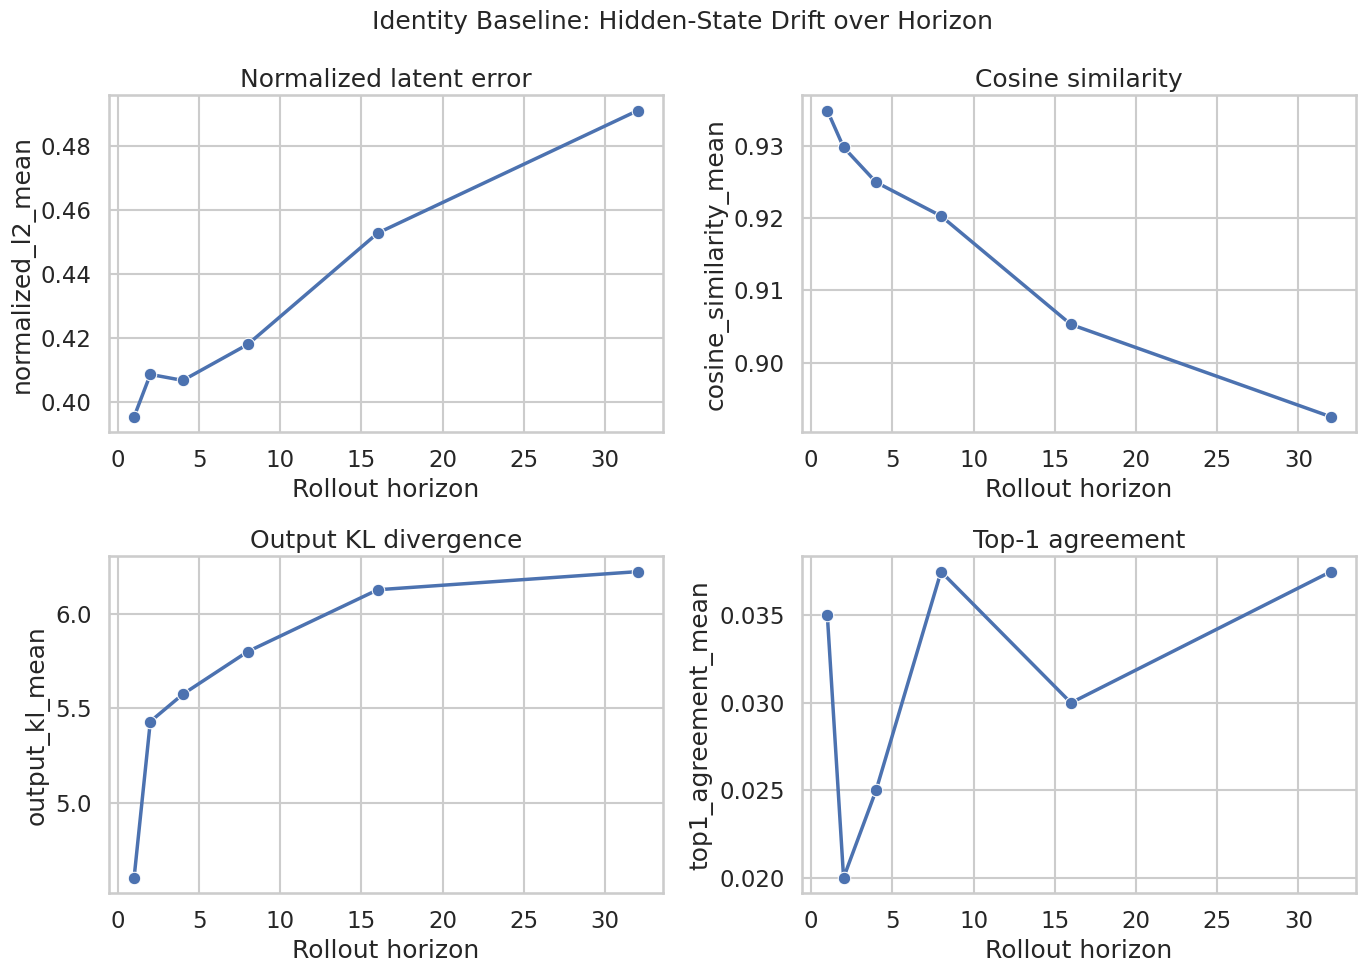

In [14]:
sns.set_theme(
    style="whitegrid",
    context="talk",
)

figure, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10),
)

plot_specs = [
    (
        "normalized_l2_mean",
        "Normalized latent error",
    ),
    (
        "cosine_similarity_mean",
        "Cosine similarity",
    ),
    (
        "output_kl_mean",
        "Output KL divergence",
    ),
    (
        "top1_agreement_mean",
        "Top-1 agreement",
    ),
]

for axis, (column, title) in zip(
    axes.flatten(),
    plot_specs,
):
    sns.lineplot(
        data=summary_df,
        x="horizon",
        y=column,
        marker="o",
        linewidth=2.5,
        ax=axis,
    )

    axis.set_title(title)
    axis.set_xlabel("Rollout horizon")

figure.suptitle(
    "Identity Baseline: Hidden-State Drift over Horizon",
    fontsize=18,
)

figure.tight_layout()

plt.show()

In [15]:
RESULT_DIRECTORY = (
    DRIVE_DIRECTORY
    / "results"
)

FIGURE_DIRECTORY = (
    RESULT_DIRECTORY
    / "figures"
)

TABLE_DIRECTORY = (
    RESULT_DIRECTORY
    / "tables"
)

FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

TABLE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

In [16]:
summary_path = (
    TABLE_DIRECTORY
    / "identity_summary.csv"
)

sample_path = (
    TABLE_DIRECTORY
    / "identity_samples.csv"
)

figure_path = (
    FIGURE_DIRECTORY
    / "identity_baseline.png"
)

summary_df.to_csv(
    summary_path,
    index=False,
)

sample_df.to_csv(
    sample_path,
    index=False,
)

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

print("Saved summary:", summary_path)
print("Saved samples:", sample_path)
print("Saved figure:", figure_path)

Saved summary: /content/drive/MyDrive/ma2288_nextlat/results/tables/identity_summary.csv
Saved samples: /content/drive/MyDrive/ma2288_nextlat/results/tables/identity_samples.csv
Saved figure: /content/drive/MyDrive/ma2288_nextlat/results/figures/identity_baseline.png


In [17]:
from google.colab import files

files.download(str(summary_path))
files.download(str(figure_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>